# Notebook 10 — Final Prediction, SHAP and Deployment Preparation

Uses the primary deployed **Soft Voting Ensemble (Top 4 Models)** for maintenance predictions, model-agnostic SHAP Explainable AI, and actionable inspection recommendations.


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)


In [2]:
# Load deployed Soft Voting Ensemble model and untouched test set
final_model = joblib.load("models/voting_ensemble_model.pkl")
test_df = pd.read_csv("data/processed/test_dataset.csv")

X_test = test_df.drop("Maintenance_Required", axis=1)
y_test = test_df["Maintenance_Required"]

print("Final Voting Ensemble model (Top 4 Models) loaded successfully.")
print("Test dataset shape:", X_test.shape)


Final Voting Ensemble model (Top 4 Models) loaded successfully.
Test dataset shape: (50000, 20)


In [3]:
# Compute predictions and test performance metrics
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame([{
    "Model": "Soft Voting Ensemble (Top 4 Deployed)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}])

print("Final Model Metrics:")
final_metrics


Final Model Metrics:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Soft Voting Ensemble (Top 4 Deployed),0.94114,0.942414,0.871448,0.905543,0.924566


<Figure size 600x500 with 0 Axes>

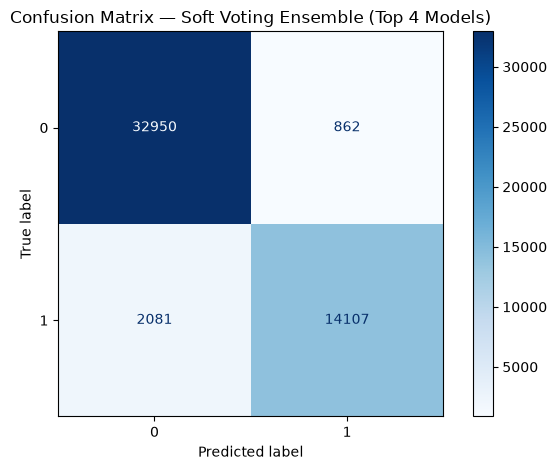

In [4]:
# Confusion Matrix for deployed Soft Voting Ensemble
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix — Soft Voting Ensemble (Top 4 Models)")
plt.tight_layout()
plt.show()


In [5]:
# Model-Agnostic SHAP Explainer setup for Soft Voting Ensemble
print("SHAP version:", shap.__version__)

X_background = X_test.sample(n=min(100, len(X_test)), random_state=42)
X_explain = X_test.sample(n=min(50, len(X_test)), random_state=42)

# Use shap.Explainer with model.predict_proba for model-agnostic explanation
explainer = shap.Explainer(final_model.predict_proba, X_background)
shap_values = explainer(X_explain)

print("SHAP explanation generated successfully.")


SHAP version: 0.52.0


PermutationExplainer explainer:   2%|▏         | 1/50 [00:00<?, ?it/s]

PermutationExplainer explainer:   6%|▌         | 3/50 [00:14<00:22,  2.05it/s]

PermutationExplainer explainer:   8%|▊         | 4/50 [00:15<00:29,  1.53it/s]

PermutationExplainer explainer:  10%|█         | 5/50 [00:16<00:32,  1.39it/s]

...

PermutationExplainer explainer:  98%|█████████▊| 49/50 [00:50<00:00,  1.35it/s]

PermutationExplainer explainer: 100%|██████████| 50/50 [00:50<00:00,  1.36it/s]

PermutationExplainer explainer: 51it [00:51,  1.31it/s]                        

PermutationExplainer explainer: 51it [00:51,  1.04s/it]

SHAP explanation generated successfully.


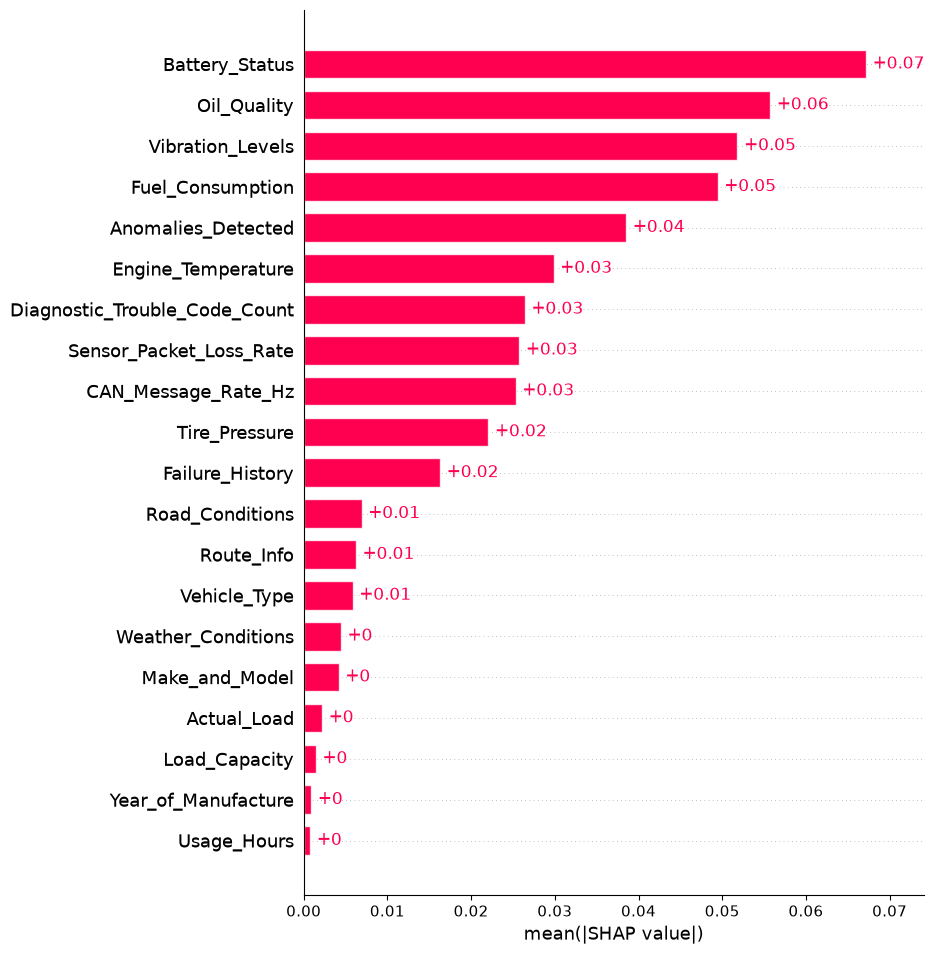

In [6]:
# Global Feature Importance Bar Plot for Class 1 (Maintenance Required)
if len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

shap.plots.bar(shap_vals_class1, max_display=20)


In [7]:
# Single Vehicle Prediction & Risk Assessment Workflow
vehicle_index = 0
vehicle_sample = X_test.iloc[[vehicle_index]]

vehicle_prediction = final_model.predict(vehicle_sample)[0]
vehicle_probability = final_model.predict_proba(vehicle_sample)[0, 1]

if vehicle_probability < 0.40:
    risk_level = "Low"
elif vehicle_probability < 0.70:
    risk_level = "Medium"
else:
    risk_level = "High"

print("Vehicle Analysis Summary:")
print("------------------------")
print(f"Prediction: {'Maintenance Required' if vehicle_prediction == 1 else 'No Maintenance Required'}")
print(f"Maintenance Probability: {vehicle_probability:.2%}")
print(f"Risk Level: {risk_level}")


Vehicle Analysis Summary:
------------------------
Prediction: No Maintenance Required
Maintenance Probability: 6.51%
Risk Level: Low


In [8]:
# Compute local SHAP contributions for single vehicle
single_shap = explainer(vehicle_sample)

if len(single_shap.shape) == 3:
    vals = single_shap.values[0, :, 1]
else:
    vals = single_shap.values[0]

contributions = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Value": vals
})
contributions["Absolute_SHAP"] = contributions["SHAP_Value"].abs()
contributions = contributions.sort_values("Absolute_SHAP", ascending=False).reset_index(drop=True)

print("Top 10 Feature Contributions for Vehicle:")
contributions.head(10)


Top 10 Feature Contributions for Vehicle:


,Feature,SHAP_Value,Absolute_SHAP
0,Battery_Status,-0.064399,0.064399
1,Oil_Quality,-0.037240,0.037240
2,Diagnostic_Trouble_Code_Count,-0.030560,0.030560
3,Fuel_Consumption,-0.030520,0.030520
4,Anomalies_Detected,-0.030181,0.030181
5,CAN_Message_Rate_Hz,-0.028098,0.028098
6,Tire_Pressure,-0.023263,0.023263
7,Sensor_Packet_Loss_Rate,-0.015175,0.015175
8,Engine_Temperature,-0.015088,0.015088
9,Vibration_Levels,-0.009189,0.009189


In [9]:
# Maintenance Recommendation Engine
def generate_recommendations(contributions, probability, prediction):
    if prediction == 0 and probability < 0.40:
        return ["Vehicle is healthy. Perform standard routine inspection according to scheduled maintenance."]
    
    recommendations = []
    top_features = contributions.head(8)["Feature"].tolist()
    
    feature_str = " ".join([str(f).lower() for f in top_features])
    
    if "engine_temperature" in feature_str:
        recommendations.append("Inspect engine cooling system, radiator, and coolant levels.")
    if "oil_quality" in feature_str:
        recommendations.append("Inspect engine oil quality, oil filter, and consider oil servicing.")
    if "vibration" in feature_str:
        recommendations.append("Inspect engine mounts, driveshaft, and mechanical vibration components.")
    if "battery" in feature_str:
        recommendations.append("Inspect battery charge, terminal contacts, and electrical alternator.")
    if "tire_pressure" in feature_str:
        recommendations.append("Inspect tire pressure, tread wear, and wheel alignment.")
    if "fuel_consumption" in feature_str:
        recommendations.append("Inspect fuel delivery system, fuel filters, and engine efficiency.")
    if "road_conditions" in feature_str:
        recommendations.append("Inspect chassis and suspension system for impact from poor road conditions.")
    if "diagnostic_trouble_code" in feature_str or "anomalies" in feature_str or "can_message" in feature_str:
        recommendations.append("Perform full OBD/CAN bus diagnostic scan to resolve active DTC anomaly codes.")
        
    if not recommendations:
        recommendations.append("Perform comprehensive powertrain and chassis inspection due to elevated maintenance risk.")
        
    return recommendations

recommendations = generate_recommendations(contributions, vehicle_probability, vehicle_prediction)

print("Recommended Inspection Areas:")
print("-----------------------------")
for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")


Recommended Inspection Areas:
-----------------------------
1. Vehicle is healthy. Perform standard routine inspection according to scheduled maintenance.
